W projekcie robiłyśmy klasteryzację pistacji na podstawie cech wyekstrahowanych z obrazów. Pracowałyśmy na dwóch wersjach danych:
1. Gotowy dataframe z cechami geometrycznymi i kolorystycznymi.
2. Własnoręcznie przygotowany dataframe z embeddingami wyciągniętymi za pomocą modeli ResNet i ViT.

Testowane algorytmy:
* KMeans
* DBSCAN
* HDBSCAN

Do oceny jakości klasteryzacji użyliśmy:
* Silhouette Score
* Calinski-Harabasz Index
* Davies-Bouldin Index
* rozkładu klas pistachio_type_encoded w klastrach

Na pierwszym zbiorze danych najlepszy wynik uzyskałyśmy dla KMeans z k=2 po PCA:
* Silhouette: 0.5186
* Calinski-Harabasz: 3286.13
* Davies-Bouldin: 0.6572
* Rozmiary klastrów: 1121 i 1027
* Szum: 0 punktów

Na danych z t-SNE najlepszy wynik to KMeans z k=4:
* Silhouette: 0.4437
* Calinski-Harabasz: 2443.89
* Davies-Bouldin: 0.7785
* Rozmiary klastrów: 594, 576, 497, 481
* Szum: 0 punktów

Dla całego zbioru embeddingów:

* KMeans z k=2 dał niezły wynik, ale klastry nie były zgodne z etykietami:
  * Klaster 0: 849 typ 0, 471 typ 1
  * Klaster 1: 383 typ 0, 445 typ 1
* Dla k=4 pojawiła się częściowa separacja:
  * Klastry 0 i 2 to głównie typ 0 (Kirmizi)
  * Klastry 1 i 3 to głównie typ 1 (Siirt)

Embeddingi tylko z ResNet

Najlepszy wynik przy k=6:
* Klastry 0, 1 i 5 zawierają głównie typ 0 (Kirmizi)
* Pozostałe klastry zawierają głównie typ 1 (Siirt)

Embeddingi tylko z ViT

Najlepszy wynik przy k=4:
* Klastry 0, 1 i 3 zawierają głównie typ 0 (Kirmizi)
* Klastry 2 i 4 zawierają głównie typ 1 (Siirt)

DBSCAN i HDBSCAN

W każdej wersji danych:
* dużo punktów było oznaczanych jako szum
* lub powstawał jeden duży klaster i kilka bardzo małych
* zmiany parametrów eps i min_samples w DBSCAN nie przynosiły stabilnych rezultatów

Wnioski:
* KMeans działał najlepiej w każdej wersji danych
* Embeddingi z ResNet i ViT pozwalały na lepszą separację niż klasyczne cechy
* DBSCAN i HDBSCAN nie były skuteczne dla tego typu danych

In [1]:
import pandas as pd

df = pd.read_csv('df_pca.csv')
df1 = pd.read_csv('tsne_df.csv')
df2 = pd.read_csv('df_selected.csv')

print(df.head())
print(df1.head())
print(df2.head())

            PC1          PC2         PC3        PC4        PC5       PC6  \
0 -20087.392990 -3361.672263  -58.540363 -32.162045 -31.614381 -0.903251   
1 -13157.476096 -3286.859643  288.445708 -17.867665  13.135173 -8.147238   
2  -7878.939350 -1110.617826 -240.429368  20.470919  -5.211596  1.611221   
3 -13936.987611  1394.592180  214.915415  -2.388804  -1.877845 -0.231508   
4  -1382.171285  1578.945247  -26.096162  25.582049  11.589405 -7.698290   

        PC7       PC8       PC9      PC10  
0 -0.728175  4.375548  0.393880  1.438826  
1  4.140676 -0.379446 -2.015130 -0.823267  
2 -1.972310 -2.235499  0.267241  0.732852  
3  0.325211  2.711977  7.662693  4.260692  
4 -0.656765 -1.484687 -1.365076 -0.125180  
        Dim1       Dim2
0  12.314322 -24.093937
1  44.396156  -5.873435
2 -12.347553 -16.970806
3  -2.551342  15.105803
4  20.468678  31.912514
           PC1       PC2       PC3
0 -3361.672263 -0.903251 -0.728175
1 -3286.859643 -8.147238  4.140676
2 -1110.617826  1.611221 -1.97

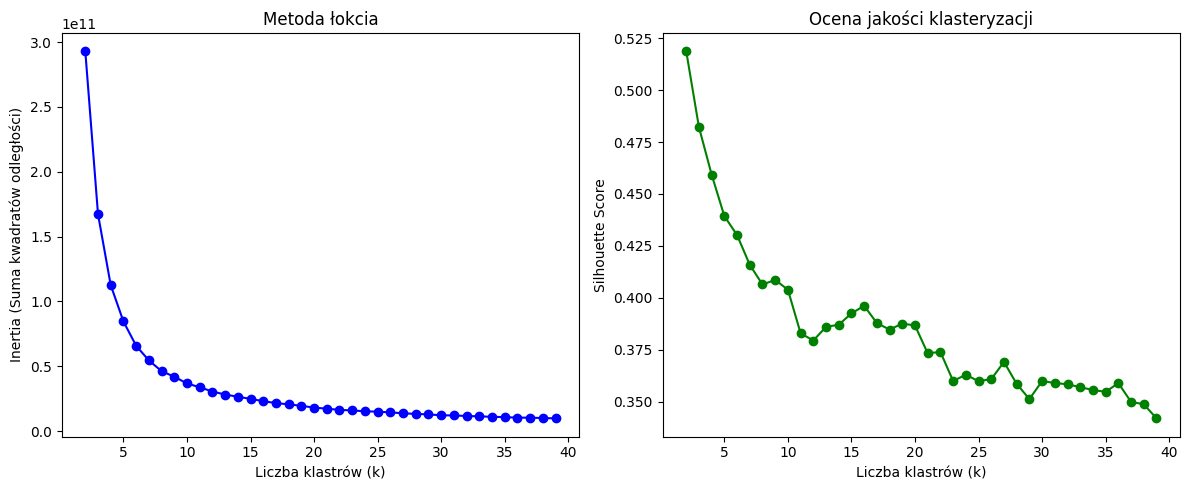

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X = df.values 
#X = StandardScaler().fit_transform(df)

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_model = None

for k in range(2, 8):
    model = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    
    print(f'k={k}, silhouette={score:.4f}')
    
    if score > best_score:
        best_score = score
        best_model = model

k=2, silhouette=0.5186
k=3, silhouette=0.4822
k=4, silhouette=0.4593
k=5, silhouette=0.4371
k=6, silhouette=0.4305
k=7, silhouette=0.4159


In [54]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from collections import Counter
import numpy as np

labels = best_model.predict(X)

sil_score = silhouette_score(X[labels != -1], labels[labels != -1])
ch_score = calinski_harabasz_score(X[labels != -1], labels[labels != -1])
db_score = davies_bouldin_score(X[labels != -1], labels[labels != -1])

noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])

print(f"\nMetryki dla najlepszego modelu (k={len(set(labels)) - (1 if -1 in labels else 0)}):")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Noise points:            {noise_points}")
print(f"Cluster sizes:           {cluster_sizes}")


Metryki dla najlepszego modelu (k=2):
Silhouette Score:        0.5186
Calinski-Harabasz Index: 3286.1296
Davies-Bouldin Index:    0.6572
Noise points:            0
Cluster sizes:           Counter({np.int32(0): 1121, np.int32(1): 1027})


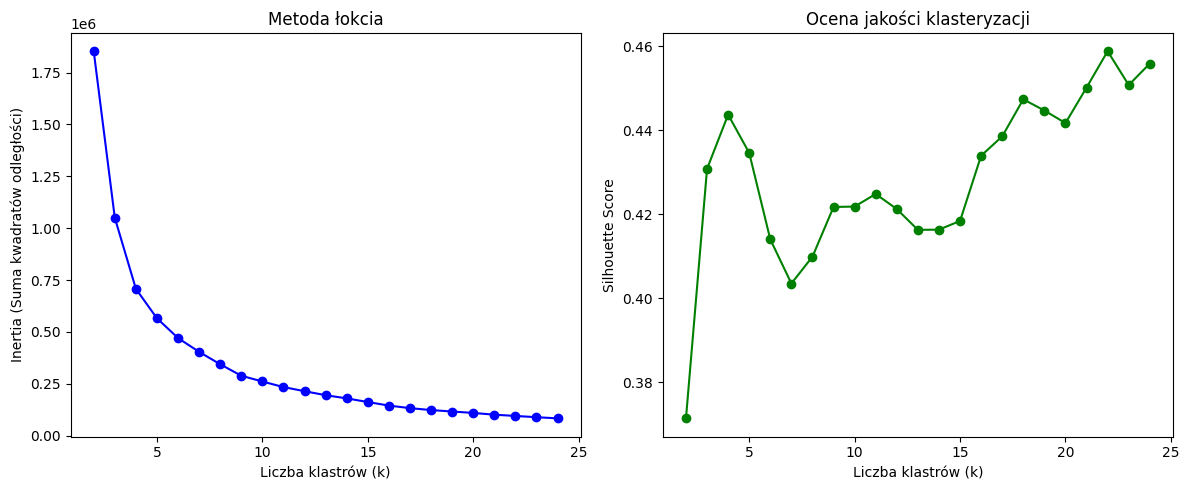

In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X1 = df1.values 

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    kmeans.fit(X1)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X1, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_model = None

for k in range(2, 10):
    model = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    labels = model.fit_predict(X1)
    score = silhouette_score(X1, labels)
    
    print(f'k={k}, silhouette={score:.4f}')
    
    if score > best_score:
        best_score = score
        best_model = model

k=2, silhouette=0.3714
k=3, silhouette=0.4308
k=4, silhouette=0.4437
k=5, silhouette=0.4346
k=6, silhouette=0.4140
k=7, silhouette=0.4035
k=8, silhouette=0.4099
k=9, silhouette=0.4218


In [57]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = best_model.predict(X1)

sil_score = silhouette_score(X1[labels != -1], labels[labels != -1])
ch_score = calinski_harabasz_score(X1[labels != -1], labels[labels != -1])
db_score = davies_bouldin_score(X1[labels != -1], labels[labels != -1])

noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])

print(f"\nMetryki dla najlepszego modelu (k={len(set(labels)) - (1 if -1 in labels else 0)}):")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Noise points:            {noise_points}")
print(f"Cluster sizes:           {cluster_sizes}")


Metryki dla najlepszego modelu (k=4):
Silhouette Score:        0.4437
Calinski-Harabasz Index: 2443.8903
Davies-Bouldin Index:    0.7785
Noise points:            0
Cluster sizes:           Counter({np.int32(2): 594, np.int32(3): 576, np.int32(0): 497, np.int32(1): 481})


In [3]:
df1_copy=df1.copy()
X = df1_copy
kmeans = KMeans(n_clusters=4, random_state=42)
df1_copy['cluster'] = kmeans.fit_predict(X)

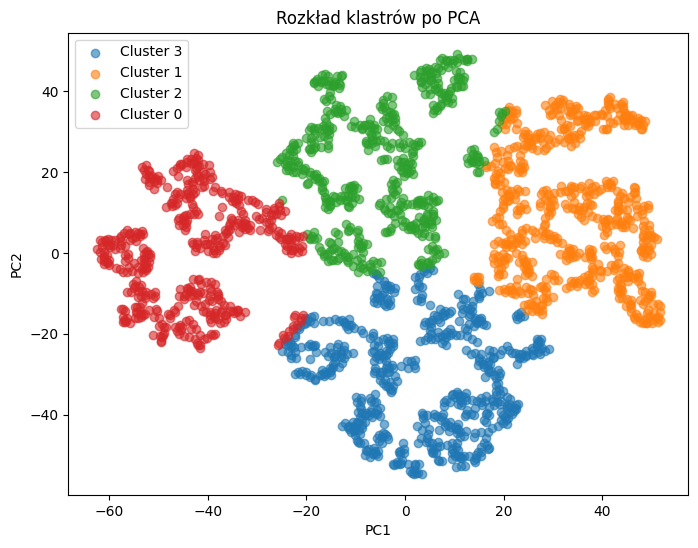

In [6]:
plt.figure(figsize=(8, 6))
for label in df1_copy['cluster'].unique():
    subset = df1_copy[df1_copy['cluster'] == label]
    plt.scatter(subset['Dim1'], subset['Dim2'], label=f'Cluster {label}', alpha=0.6)
    
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Rozkład klastrów po PCA')
plt.show()

PCA -> n_components=2

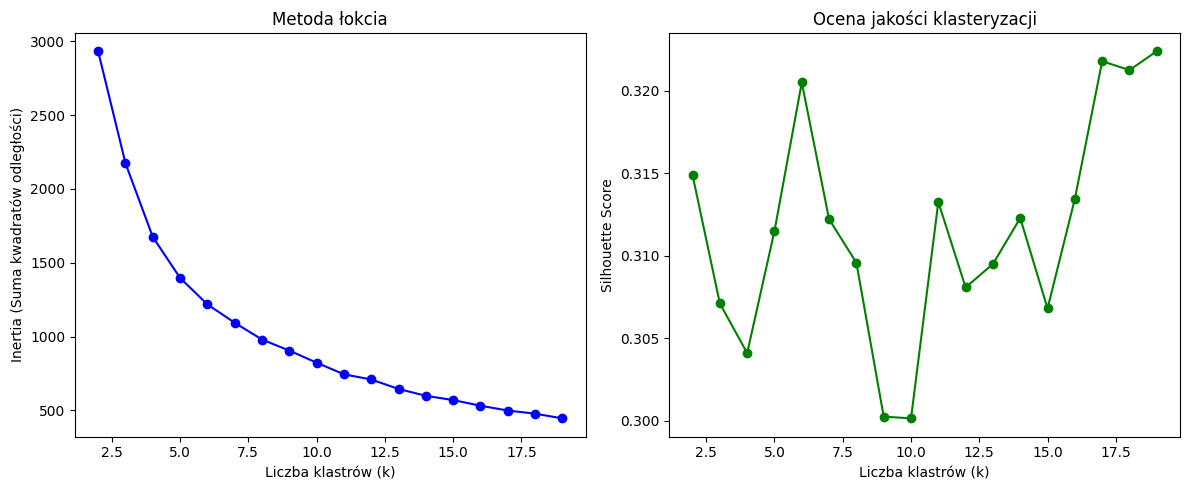

In [79]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [80]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_model = None

for k in range(2, 10):
    model = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    print(f'k={k}, silhouette={score:.4f}')
    
    if score > best_score:
        best_score = score
        best_model = model

k=2, silhouette=0.3156
k=3, silhouette=0.3280
k=4, silhouette=0.3141
k=5, silhouette=0.3135
k=6, silhouette=0.3230
k=7, silhouette=0.3233
k=8, silhouette=0.3218
k=9, silhouette=0.3191


In [81]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = best_model.predict(X_pca)

sil_score = silhouette_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)

print(f"\nMetryki dla najlepszego modelu (k={best_model.n_clusters}):")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")


Metryki dla najlepszego modelu (k=3):
Silhouette Score:        0.3280
Calinski-Harabasz Index: 1171.3197
Davies-Bouldin Index:    0.9460


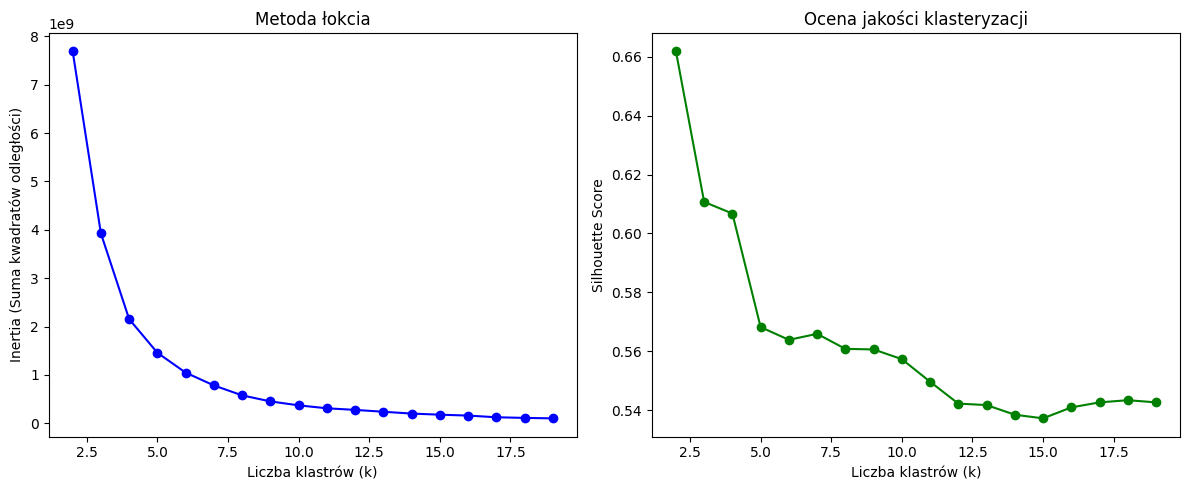

In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X2 = df2.values 

inertia = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X2)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X2, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_model = None

for k in range(2, 10):
    model = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    labels = model.fit_predict(X2)
    score = silhouette_score(X2, labels)
    
    print(f'k={k}, silhouette={score:.4f}')
    
    if score > best_score:
        best_score = score
        best_model = model

k=2, silhouette=0.6619
k=3, silhouette=0.6102
k=4, silhouette=0.6068
k=5, silhouette=0.5747
k=6, silhouette=0.5638
k=7, silhouette=0.5650
k=8, silhouette=0.5696
k=9, silhouette=0.5588


In [60]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

labels = best_model.predict(X2)

sil_score = silhouette_score(X2[labels != -1], labels[labels != -1])
ch_score = calinski_harabasz_score(X2[labels != -1], labels[labels != -1])
db_score = davies_bouldin_score(X2[labels != -1], labels[labels != -1])

noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])

print(f"\nMetryki dla najlepszego modelu (k={len(set(labels)) - (1 if -1 in labels else 0)}):")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Noise points:            {noise_points}")
print(f"Cluster sizes:           {cluster_sizes}")

#najlepszy dla K-Means siholuete


Metryki dla najlepszego modelu (k=2):
Silhouette Score:        0.6619
Calinski-Harabasz Index: 3703.3474
Davies-Bouldin Index:    0.5642
Noise points:            0
Cluster sizes:           Counter({np.int32(0): 1714, np.int32(1): 434})


DBSCAN

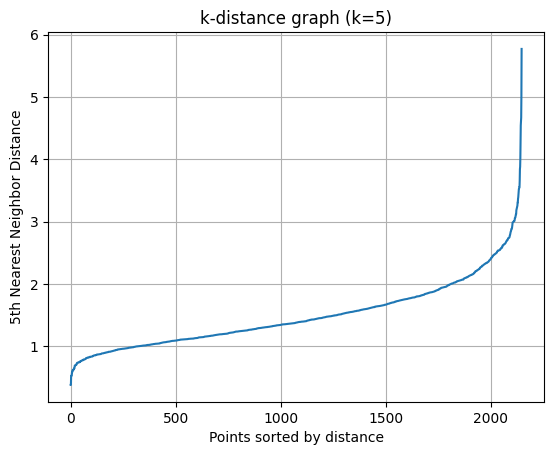

In [72]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df)
#X = df.values
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, 1])  # 4 = n_neighbors - 1
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph (k=5)")
plt.grid()
plt.show()

In [73]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

best_result = None

for eps in np.arange(1.5, 3, 0.1):
    for min_samples in range(5, 6):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            dbi = davies_bouldin_score(X, labels)
            print(f'eps={eps:.1f}, min_samples={min_samples} => Silhouette: {sil:.4f}, DBI: {dbi:.4f}')
            
            if best_result is None or sil > best_result['silhouette']:
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil,
                    'davies_bouldin': dbi
                }

print("\nNajlepszy wynik:")
print(best_result)

eps=1.5, min_samples=5 => Silhouette: -0.0903, DBI: 3.3976
eps=1.8, min_samples=5 => Silhouette: -0.0281, DBI: 2.7705
eps=1.9, min_samples=5 => Silhouette: -0.1280, DBI: 2.0997
eps=2.0, min_samples=5 => Silhouette: -0.0656, DBI: 2.2889
eps=2.1, min_samples=5 => Silhouette: -0.0613, DBI: 2.5390
eps=2.2, min_samples=5 => Silhouette: 0.0366, DBI: 2.6390
eps=2.3, min_samples=5 => Silhouette: 0.1560, DBI: 2.7216
eps=2.4, min_samples=5 => Silhouette: 0.3093, DBI: 3.1852
eps=2.5, min_samples=5 => Silhouette: 0.3312, DBI: 3.0585
eps=2.6, min_samples=5 => Silhouette: 0.3536, DBI: 2.9044
eps=2.7, min_samples=5 => Silhouette: 0.3754, DBI: 2.8042
eps=2.8, min_samples=5 => Silhouette: 0.3951, DBI: 2.9239
eps=2.9, min_samples=5 => Silhouette: 0.4113, DBI: 2.7476

Najlepszy wynik:
{'eps': np.float64(2.9000000000000012), 'min_samples': 5, 'silhouette': np.float64(0.41128862326095394), 'davies_bouldin': np.float64(2.7476124090895535)}


In [75]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
from sklearn.decomposition import PCA

db = DBSCAN(eps=2.9000000000000012, min_samples=5)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
silhouette = silhouette_score(X_scaled2[labels != -1], labels[labels != -1])
davies_bouldin = davies_bouldin_score(X_scaled2[labels != -1], labels[labels != -1])
    
noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])
    
print(f'n_clusters: {n_clusters}')
print(f'Silhouette Score:        {silhouette:.4f}')
print(f'Davies-Bouldin Index:    {davies_bouldin:.4f}')
print(f'Noise points:            {noise_points}')
print(f'Cluster sizes:           {cluster_sizes}')

n_clusters: 2
Silhouette Score:        0.3588
Davies-Bouldin Index:    0.5133
Noise points:            71
Cluster sizes:           Counter({np.int64(0): 2072, np.int64(1): 5})


In [56]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import DBSCAN

best_result = {'eps': None, 'min_samples': None, 'silhouette': -1, 'davies_bouldin': float('inf')}

for eps in np.arange(2.0, 3.5, 0.1):
    for min_samples in range(3, 10):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            dbi = davies_bouldin_score(X, labels)
            
            if sil > best_result['silhouette']:  
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil,
                    'davies_bouldin': dbi,
                    'n_clusters': n_clusters
                }

print("Najlepszy wynik:", best_result)

Najlepszy wynik: {'eps': np.float64(3.200000000000001), 'min_samples': 3, 'silhouette': np.float64(0.4616661505206641), 'davies_bouldin': np.float64(2.052326497670103), 'n_clusters': 2}


In [57]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
from sklearn.decomposition import PCA


db = DBSCAN(eps=3.200000000000001, min_samples=3)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
if n_clusters > 1:
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    print(f'n_clusters: {n_clusters}')
    print(f'Silhouette Score: {silhouette:.4f}')
    print(f'Davies-Bouldin Index: {davies_bouldin:.4f}')
else:
    print("Za mało klastrów do obliczenia metryk.")

n_clusters: 2
Silhouette Score: 0.4617
Davies-Bouldin Index: 2.0523


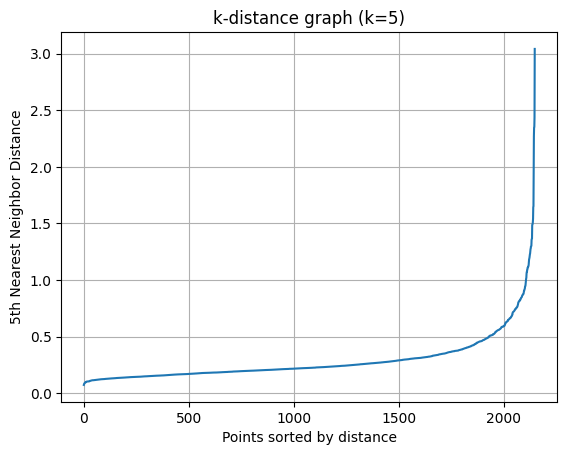

In [62]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
X_scaled2 = StandardScaler().fit_transform(df2)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled2)
distances, indices = neighbors_fit.kneighbors(X_scaled2)
distances = np.sort(distances[:, 4]) 
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph (k=5)")
plt.grid()
plt.show()

In [65]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

best_result = None

for eps in np.arange(0.3, 1.2, 0.1):
    for min_samples in range(5, 6):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled2)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X_scaled2, labels)
            dbi = davies_bouldin_score(X_scaled2, labels)
            print(f'eps={eps:.1f}, min_samples={min_samples} => Silhouette: {sil:.4f}, DBI: {dbi:.4f}')
            
            if best_result is None or sil > best_result['silhouette']:
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil,
                    'davies_bouldin': dbi
                }

print("\nNajlepszy wynik:")
print(best_result)

eps=0.3, min_samples=5 => Silhouette: -0.2619, DBI: 2.1946
eps=0.4, min_samples=5 => Silhouette: -0.0563, DBI: 2.3022
eps=0.5, min_samples=5 => Silhouette: 0.3315, DBI: 1.4218
eps=0.6, min_samples=5 => Silhouette: 0.4426, DBI: 2.6909
eps=0.8, min_samples=5 => Silhouette: 0.5590, DBI: 1.3851
eps=0.9, min_samples=5 => Silhouette: 0.5889, DBI: 1.4495

Najlepszy wynik:
{'eps': np.float64(0.9000000000000001), 'min_samples': 5, 'silhouette': np.float64(0.5889183166198573), 'davies_bouldin': np.float64(1.4494950115469276)}


In [70]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

eps = 0.3
min_samples = 5
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled2)


n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

if n_clusters > 1:
    silhouette = silhouette_score(X_scaled2[labels != -1], labels[labels != -1])
    davies_bouldin = davies_bouldin_score(X_scaled2[labels != -1], labels[labels != -1])
    
    noise_points = np.sum(labels == -1)
    cluster_sizes = Counter(labels[labels != -1])
    
    print(f'n_clusters: {n_clusters}')
    print(f'Silhouette Score:        {silhouette:.4f}')
    print(f'Davies-Bouldin Index:    {davies_bouldin:.4f}')
    print(f'Noise points:            {noise_points}')
    print(f'Cluster sizes:           {cluster_sizes}')
else:
    print("Za mało klastrów do obliczenia metryk.")

n_clusters: 7
Silhouette Score:        -0.1953
Davies-Bouldin Index:    0.7375
Noise points:            432
Cluster sizes:           Counter({np.int64(0): 1684, np.int64(1): 8, np.int64(4): 5, np.int64(5): 5, np.int64(2): 5, np.int64(6): 5, np.int64(3): 4})


In [19]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import numpy as np
import matplotlib.pyplot as plt

X = StandardScaler().fit_transform(df.values)

best_score = -1
best_params = {}

min_samples_list = [4, 5, 8, 10, 12]

for min_samples in min_samples_list:
   
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    distances = np.sort(distances[:, min_samples - 1])

    try:
        knee = KneeLocator(range(len(distances)), distances, curve="convex", direction="increasing")
        eps = distances[knee.knee]

        #
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X[labels != -1], labels[labels != -1])
            print(f"min_samples={min_samples}, eps={eps:.4f}, silhouette={score:.4f}, clusters={n_clusters}")

            if score > best_score:
                best_score = score
                best_params = {
                    'min_samples': min_samples,
                    'eps': eps,
                    'silhouette': score,
                    'n_clusters': n_clusters
                }

    except Exception as e:
        print(f"min_samples={min_samples}: nie udało się wykryć łokcia ({e})")

print(" Najlepsze parametry:")
print(best_params)

min_samples=4, eps=3.2704, silhouette=0.6596, clusters=2
min_samples=8, eps=7.7637, silhouette=0.6557, clusters=3
 Najlepsze parametry:
{'min_samples': 4, 'eps': np.float64(3.27042082100734), 'silhouette': np.float64(0.6596132742498101), 'n_clusters': 2}


PCA -> jeszcze zmiejszam wymiar 

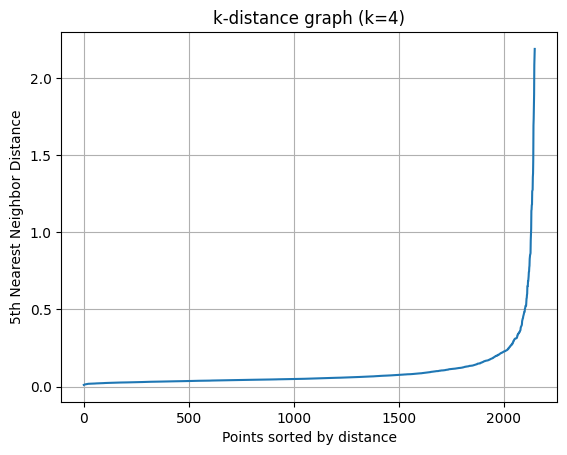

In [41]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

X_scaled = StandardScaler().fit_transform(df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 3]) 
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph (k=4)")
plt.grid()
plt.show()

In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score


best_result = None

for eps in np.arange(0.2, 0.5, 0.1):
    for min_samples in range(2,):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X_pca, labels)
            dbi = davies_bouldin_score(X_pca, labels)
            print(f'eps={eps:.1f}, min_samples={min_samples} => Silhouette: {sil:.4f}, DBI: {dbi:.4f}')
            
            if best_result is None or sil > best_result['silhouette']:
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil,
                    'davies_bouldin': dbi
                }

print("\nNajlepszy wynik:")
print(best_result)

eps=0.2, min_samples=2 => Silhouette: -0.1156, DBI: 2.7198
eps=0.2, min_samples=3 => Silhouette: 0.0086, DBI: 2.7215
eps=0.2, min_samples=4 => Silhouette: 0.0628, DBI: 4.1432
eps=0.3, min_samples=2 => Silhouette: 0.2544, DBI: 3.9674
eps=0.3, min_samples=3 => Silhouette: 0.2962, DBI: 5.3898
eps=0.3, min_samples=4 => Silhouette: 0.3597, DBI: 5.5703
eps=0.4, min_samples=2 => Silhouette: 0.4909, DBI: 1.9129
eps=0.4, min_samples=3 => Silhouette: 0.7255, DBI: 2.0675

Najlepszy wynik:
{'eps': np.float64(0.4000000000000001), 'min_samples': 3, 'silhouette': np.float64(0.7254736813522117), 'davies_bouldin': np.float64(2.067528102037925)}


In [49]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# X = StandardScaler().fit_transform(df.values)

best_score = -1
best_params = {}

min_samples_list = [4, 9, 5, 8, 10, 12]

for min_samples in min_samples_list:

    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_pca)
    distances, indices = neighbors_fit.kneighbors(X_pca)
    distances = np.sort(distances[:, min_samples - 1])

    try:
        knee = KneeLocator(range(len(distances)), distances, curve="convex", direction="increasing")
        eps = distances[knee.knee]

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(X_pca[labels != -1], labels[labels != -1])
            noise_points = np.sum(labels == -1)
            cluster_sizes = Counter(labels[labels != -1])

            print(f"min_samples={min_samples}, eps={eps:.4f}, silhouette={score:.4f}, clusters={n_clusters}")
            print(f"Noise points: {noise_points}")
            print(f"Cluster sizes: {cluster_sizes}")

            if score > best_score:
                best_score = score
                best_params = {
                    'min_samples': min_samples,
                    'eps': eps,
                    'silhouette': score,
                    'n_clusters': n_clusters,
                    'noise_points': noise_points,
                    'cluster_sizes': cluster_sizes
                }

    except Exception as e:
        print(f"min_samples={min_samples}: nie udało się wykryć łokcia ({e})")

print("\nNajlepsze parametry:")
print(best_params)

min_samples=4, eps=0.6509, silhouette=0.8518, clusters=3
Noise points: 21
Cluster sizes: Counter({np.int64(0): 2118, np.int64(1): 5, np.int64(2): 4})

Najlepsze parametry:
{'min_samples': 4, 'eps': np.float64(0.6508779609320274), 'silhouette': np.float64(0.8517916640135622), 'n_clusters': 3, 'noise_points': np.int64(21), 'cluster_sizes': Counter({np.int64(0): 2118, np.int64(1): 5, np.int64(2): 4})}


HDBSCAN (musze dopracowac)

In [94]:
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
labels = clusterer.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f'n_clusters: {n_clusters}')

if n_clusters > 1:
    sil = silhouette_score(X_pca, labels)
    dbi = davies_bouldin_score(X_pca, labels)
    print(f'Silhouette Score: {sil:.4f}')
    print(f'Davies-Bouldin Index: {dbi:.4f}')
else:
    print("Za mało klastrów do oceny.")

C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


n_clusters: 2
Silhouette Score: 0.4326
Davies-Bouldin Index: 4.1161


In [96]:
import hdbscan
from sklearn.metrics import silhouette_score
import numpy as np

best_score = -1
best_params = None

for min_cluster_size in [5, 10, 20]:
    for min_samples in [None, 5, 10]:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='euclidean')
        labels = clusterer.fit_predict(X_pca)

        mask = labels != -1
        if np.sum(mask) > 1:
            score = silhouette_score(X_pca[mask], labels[mask])
            if score > best_score:
                best_score = score
                best_params = {
                    'min_cluster_size': min_cluster_size,
                    'min_samples': min_samples,
                }

print("Najlepsze parametry:", best_params)
print("Najlepszy silhouette score:", best_score)

C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\karo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprec

Najlepsze parametry: {'min_cluster_size': 5, 'min_samples': None}
Najlepszy silhouette score: 0.45383203315158466


W tej części klasteryzacja została zrobiona na własnych danych wyciągniętych z obrazów.

In [93]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [94]:
df_resnet = pd.read_csv('df_all_1.csv')
df_vit = pd.read_csv('shapes_vit.csv')
df_resnet_pca= pd.read_csv('df_resnet_pca.csv')
df_vit_pca = pd.read_csv('shapes_vit_pca.csv')

Zrobienie PCA dla połączonych danych otrzymanych z modeli resnet i vit

In [95]:
df_all = pd.merge(df_resnet, df_vit, on="filename")

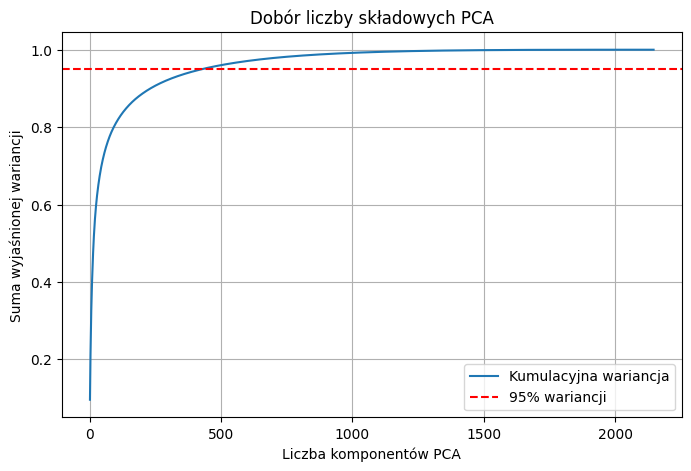

Wystarczy 429 komponentów do zachowania 95% informacji.


In [96]:
X = df_all.drop(columns=["filename"])
X.columns = X.columns.astype(str)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca_all = pca.fit_transform(X_scaled) 

cum_var = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(cum_var, label="Kumulacyjna wariancja")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% wariancji")
plt.xlabel("Liczba komponentów PCA")
plt.ylabel("Suma wyjaśnionej wariancji")
plt.title("Dobór liczby składowych PCA")
plt.grid(True)
plt.legend()
plt.show()

n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Wystarczy {n_components} komponentów do zachowania 95% informacji.")

In [97]:
pca_opt = PCA(n_components=n_components)
X_resnet_pca = pca_opt.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_resnet_pca, columns=[f"PC{i+1}" for i in range(n_components)])
df_pca["filename"] = df_all["filename"].values

Wyciągnięcie rodzaju pistacji do oddzielnej kolumny dla możliwości oceny klasteryzacji w przyszłości

In [98]:
import re
def extract_type(filename):
    match = re.match(r'([a-zA-Z]+)', filename)
    return match.group(1).lower() if match else 'unknown'

In [99]:
df_pca['pistachio_type'] = df_pca['filename'].apply(extract_type)
df_pca['pistachio_type'].value_counts()
etykieta_map = {
    'kirmizi': 0,
    'siirt': 1
}
df_pca['pistachio_type_encoded'] = df_pca['pistachio_type'].map(etykieta_map)
df_pca['pistachio_type_encoded'].value_counts()

pistachio_type_encoded
0    1232
1     916
Name: count, dtype: int64

In [100]:
df_resnet_pca['pistachio_type'] = df_resnet_pca['filename'].apply(extract_type)
df_resnet_pca['pistachio_type'].value_counts()
etykieta_map = {
    'kirmizi': 0,
    'siirt': 1
}
df_resnet_pca['pistachio_type_encoded'] = df_resnet_pca['pistachio_type'].map(etykieta_map)
df_resnet_pca['pistachio_type_encoded'].value_counts()

pistachio_type_encoded
0    1232
1     916
Name: count, dtype: int64

In [101]:
df_vit_pca['pistachio_type'] = df_vit_pca['filename'].apply(extract_type)
df_vit_pca['pistachio_type'].value_counts()
etykieta_map = {
    'kirmizi': 0,
    'siirt': 1
}
df_vit_pca['pistachio_type_encoded'] = df_vit_pca['pistachio_type'].map(etykieta_map)
df_vit_pca['pistachio_type_encoded'].value_counts()

pistachio_type_encoded
0    1232
1     916
Name: count, dtype: int64

In [102]:
df_pca_copy = df_pca.copy()
df_pca_copy.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC423,PC424,PC425,PC426,PC427,PC428,PC429,filename,pistachio_type,pistachio_type_encoded
0,0.194712,-22.051676,-5.167302,-6.702526,-0.445801,-1.698404,0.467875,-7.896684,-3.233660,6.107592,...,0.104181,-0.202404,0.391603,0.324335,0.190983,0.004123,-0.745335,kirmizi (1).jpg,kirmizi,0
1,-19.589283,-13.726288,-2.288669,1.831107,-2.287663,-5.773524,-9.959004,12.865578,9.575318,6.997399,...,-0.253038,0.152521,-0.011924,0.075651,0.196779,0.576208,0.281170,kirmizi (10).jpg,kirmizi,0
2,8.625244,-1.821266,9.637932,-11.614676,9.166008,2.770771,15.009316,-7.818260,-10.980262,-7.767596,...,0.249025,0.514209,-0.145273,0.258718,-0.882969,0.114371,-0.145647,kirmizi (11).jpg,kirmizi,0
3,-3.856548,-17.693206,8.970494,17.634634,15.218493,11.543478,-7.617486,12.540399,9.367644,5.179373,...,0.596049,-0.107307,-0.376038,0.301090,-0.037336,0.855761,0.132147,kirmizi (12).jpg,kirmizi,0
4,-17.062005,-2.570202,13.446926,11.487373,10.947447,-1.218870,-23.831213,-2.797485,4.535761,-7.252758,...,0.174999,0.307570,-0.384885,0.917544,-0.159767,-0.669713,-0.523078,kirmizi (13).jpg,kirmizi,0


Próba modelu KMeans z dwoma klastrami 

In [103]:
from sklearn.cluster import KMeans

X = df_pca_copy.drop(columns=['filename', 'pistachio_type', 'pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=2, random_state=66)
df_pca_copy['cluster'] = kmeans.fit_predict(X)

In [104]:
df_pca_copy['cluster'].value_counts()

cluster
0    1320
1     828
Name: count, dtype: int64

Wychodzą dobrze podzielone klastry, które doprowadzają do podejrzenia że do zerowego klastra były przydzielone pistacje rodzaju kirmizi,
których oryginalnie jest około 1200, a do pierwszego siirt, których jest około 800

In [106]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X_kmeans = X.values 
labels_kmeans = df_pca_copy['cluster'].values

sil = silhouette_score(X_kmeans, labels_kmeans)
calinski = calinski_harabasz_score(X_kmeans, labels_kmeans)
davies = davies_bouldin_score(X_kmeans, labels_kmeans)

print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")

Silhouette Score: 0.0877
Calinski-Harabasz Index: 168.7397
Davies-Bouldin Index: 3.4471


In [113]:
pd.crosstab(df_pca_copy['cluster'], df_pca_copy['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,849,471
1,383,445


Tu widać że podejrzenia były mylne, model dobrze wybrał 849 pistacji z kirmizi, 445 z siirt, ale dużo też pomylił

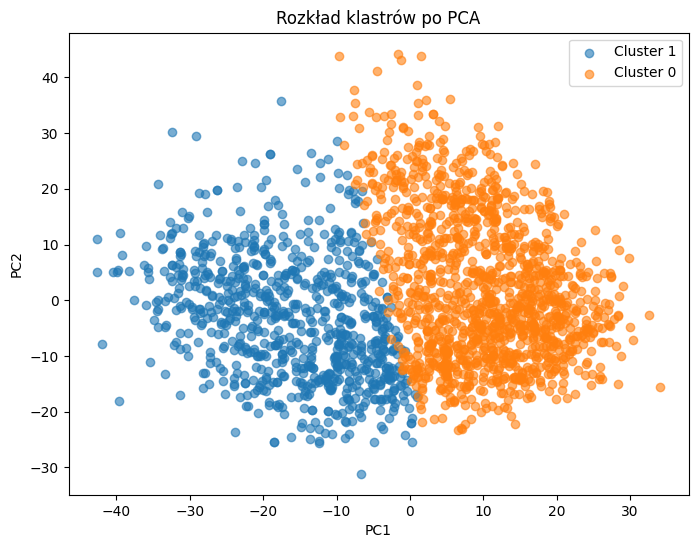

In [114]:
plt.figure(figsize=(8, 6))
for label in df_pca_copy['cluster'].unique():
    subset = df_pca_copy[df_pca_copy['cluster'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {label}', alpha=0.6)
    
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Rozkład klastrów po PCA')
plt.show()

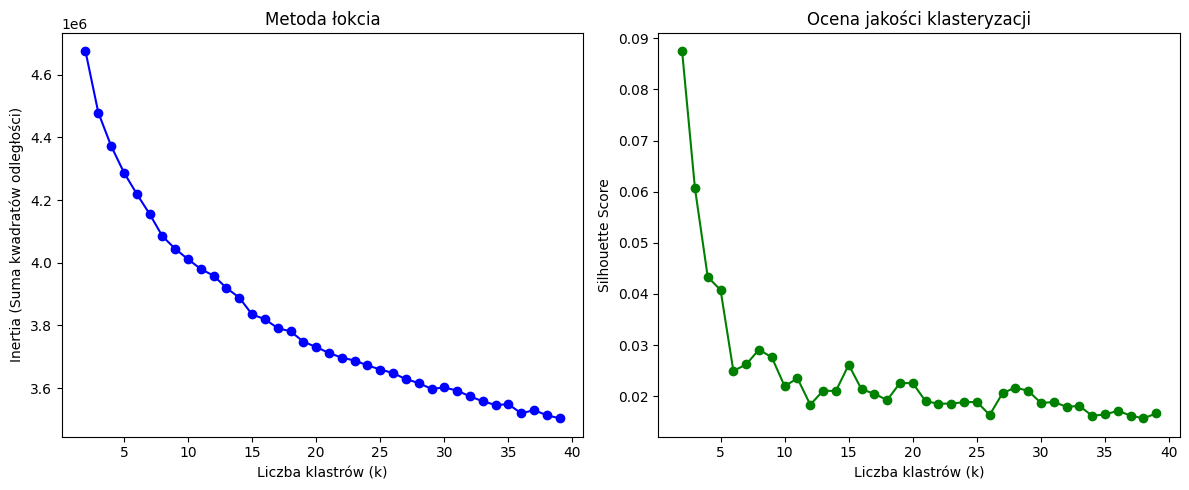

In [149]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df=df_pca.drop(columns=['filename',	'pistachio_type',	'pistachio_type_encoded'])

X = df.values

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

Próba dobrania liczby klastrów

In [150]:
results = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=66)
    labels = kmeans.fit_predict(X)  

    sil = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)

    results.append((k, sil, calinski, davies))

df_kmeans_scores = pd.DataFrame(results, columns=['k', 'silhouette', 'calinski', 'davies'])

print(df_kmeans_scores)

   k  silhouette    calinski    davies
0  2    0.087683  168.739658  3.447095
1  3    0.060623  134.846695  3.355161
2  4    0.049511  109.683606  3.620292
3  5    0.041072   94.661517  3.551172
4  6    0.040456   85.545867  3.429777
5  7    0.039067   76.838518  3.565640
6  8    0.025500   69.334082  3.481150
7  9    0.028883   65.956303  3.420301


In [151]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC423,PC424,PC425,PC426,PC427,PC428,PC429,filename,pistachio_type,pistachio_type_encoded
0,0.194712,-22.051676,-5.167302,-6.702526,-0.445801,-1.698404,0.467875,-7.896684,-3.233660,6.107592,...,0.104181,-0.202404,0.391603,0.324335,0.190983,0.004123,-0.745335,kirmizi (1).jpg,kirmizi,0
1,-19.589283,-13.726288,-2.288669,1.831107,-2.287663,-5.773524,-9.959004,12.865578,9.575318,6.997399,...,-0.253038,0.152521,-0.011924,0.075651,0.196779,0.576208,0.281170,kirmizi (10).jpg,kirmizi,0
2,8.625244,-1.821266,9.637932,-11.614676,9.166008,2.770771,15.009316,-7.818260,-10.980262,-7.767596,...,0.249025,0.514209,-0.145273,0.258718,-0.882969,0.114371,-0.145647,kirmizi (11).jpg,kirmizi,0
3,-3.856548,-17.693206,8.970494,17.634634,15.218493,11.543478,-7.617486,12.540399,9.367644,5.179373,...,0.596049,-0.107307,-0.376038,0.301090,-0.037336,0.855761,0.132147,kirmizi (12).jpg,kirmizi,0
4,-17.062005,-2.570202,13.446926,11.487373,10.947447,-1.218870,-23.831213,-2.797485,4.535761,-7.252758,...,0.174999,0.307570,-0.384885,0.917544,-0.159767,-0.669713,-0.523078,kirmizi (13).jpg,kirmizi,0


In [165]:
df_pca_copy2 = df_pca.copy()
df_pca_copy2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC423,PC424,PC425,PC426,PC427,PC428,PC429,filename,pistachio_type,pistachio_type_encoded
0,0.194712,-22.051676,-5.167302,-6.702526,-0.445801,-1.698404,0.467875,-7.896684,-3.233660,6.107592,...,0.104181,-0.202404,0.391603,0.324335,0.190983,0.004123,-0.745335,kirmizi (1).jpg,kirmizi,0
1,-19.589283,-13.726288,-2.288669,1.831107,-2.287663,-5.773524,-9.959004,12.865578,9.575318,6.997399,...,-0.253038,0.152521,-0.011924,0.075651,0.196779,0.576208,0.281170,kirmizi (10).jpg,kirmizi,0
2,8.625244,-1.821266,9.637932,-11.614676,9.166008,2.770771,15.009316,-7.818260,-10.980262,-7.767596,...,0.249025,0.514209,-0.145273,0.258718,-0.882969,0.114371,-0.145647,kirmizi (11).jpg,kirmizi,0
3,-3.856548,-17.693206,8.970494,17.634634,15.218493,11.543478,-7.617486,12.540399,9.367644,5.179373,...,0.596049,-0.107307,-0.376038,0.301090,-0.037336,0.855761,0.132147,kirmizi (12).jpg,kirmizi,0
4,-17.062005,-2.570202,13.446926,11.487373,10.947447,-1.218870,-23.831213,-2.797485,4.535761,-7.252758,...,0.174999,0.307570,-0.384885,0.917544,-0.159767,-0.669713,-0.523078,kirmizi (13).jpg,kirmizi,0


In [166]:
X = df_pca_copy2.drop(columns=['filename', 'pistachio_type', 'pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=4, random_state=66)
df_pca_copy2['cluster'] = kmeans.fit_predict(X)
df_pca_copy2['cluster'].value_counts()

cluster
0    714
2    594
1    489
3    351
Name: count, dtype: int64

In [167]:
pd.crosstab(df_pca_copy2['cluster'], df_pca_copy2['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,669,45
1,29,460
2,476,118
3,58,293


In [117]:
df_resnet_pca_copy = df_resnet_pca.copy()
df_resnet_pca_copy.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC338,PC339,PC340,PC341,PC342,PC343,PC344,filename,pistachio_type,pistachio_type_encoded
0,-3.551248,-17.716654,-3.624884,-9.096153,0.873164,-3.028066,-7.442551,-1.202262,6.060190,4.015378,...,-0.249735,-0.236001,0.457911,1.572232,0.056190,-0.393799,-0.622427,kirmizi (1).jpg,kirmizi,0
1,18.114607,-10.628550,-0.125958,-1.240595,-0.496131,-4.580767,4.518785,4.638251,-17.036196,9.377854,...,-0.584974,0.791133,0.687179,-0.438755,-0.238210,-0.161150,-0.207785,kirmizi (10).jpg,kirmizi,0
2,-12.019251,1.186817,8.105490,-10.688737,8.078110,3.220982,1.191720,-8.353822,15.078301,-9.268645,...,-0.726261,-0.557533,0.182393,-0.143124,0.726360,-0.138818,-0.047433,kirmizi (11).jpg,kirmizi,0
3,5.073485,-14.614056,9.726931,16.452125,8.826621,17.303189,6.546224,8.572450,0.867451,-0.375183,...,-0.331342,-0.904977,0.742135,-0.546309,0.326899,-0.757499,0.353910,kirmizi (12).jpg,kirmizi,0
4,15.393349,0.993230,10.639720,12.965910,10.972967,2.459127,-12.351388,0.599412,-12.540456,-7.980769,...,0.046954,-0.711882,-0.693842,0.667925,1.713752,-0.709272,0.017899,kirmizi (13).jpg,kirmizi,0


In [123]:
X = df_resnet_pca_copy.drop(columns=['filename','pistachio_type','pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=2, random_state=66)
df_resnet_pca_copy['cluster'] = kmeans.fit_predict(X)

In [124]:
df_resnet_pca_copy['cluster'].value_counts()

cluster
0    1319
1     829
Name: count, dtype: int64

In [125]:
X_kmeans = X.values 
labels_kmeans = df_resnet_pca_copy['cluster'].values

sil = silhouette_score(X_kmeans, labels_kmeans)
calinski = calinski_harabasz_score(X_kmeans, labels_kmeans)
davies = davies_bouldin_score(X_kmeans, labels_kmeans)

print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")

Silhouette Score: 0.0859
Calinski-Harabasz Index: 162.1915
Davies-Bouldin Index: 3.5053


In [126]:
pd.crosstab(df_resnet_pca_copy['cluster'], df_resnet_pca_copy['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,882,437
1,350,479


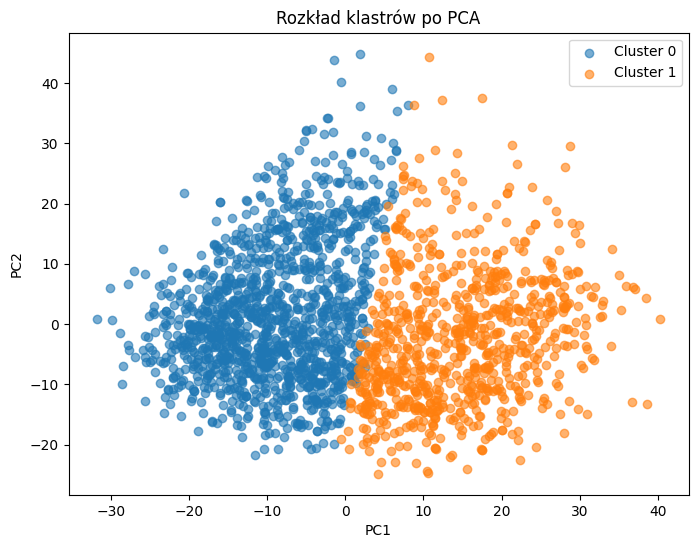

In [121]:
plt.figure(figsize=(8, 6))
for label in df_resnet_pca_copy['cluster'].unique():
    subset = df_resnet_pca_copy[df_resnet_pca_copy['cluster'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {label}', alpha=0.6)
    
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Rozkład klastrów po PCA')
plt.show()

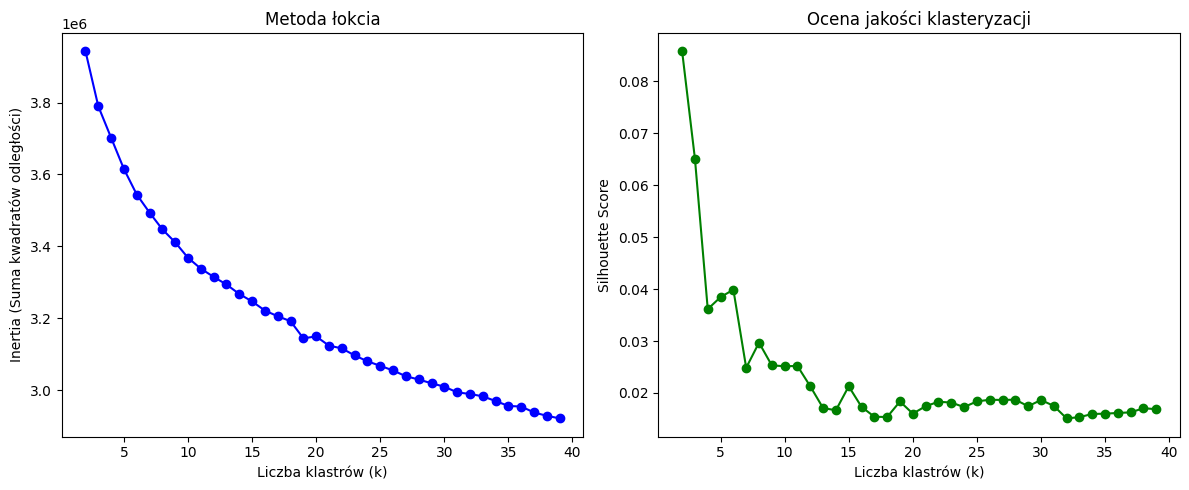

In [147]:
df=df_resnet_pca.drop(columns=['filename',	'pistachio_type',	'pistachio_type_encoded'])

X = df.values 

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [148]:
results = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=66)
    labels = kmeans.fit_predict(X)  

    sil = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)

    results.append((k, sil, calinski, davies))

df_kmeans_scores = pd.DataFrame(results, columns=['k', 'silhouette', 'calinski', 'davies'])

print(df_kmeans_scores)

   k  silhouette    calinski    davies
0  2    0.085825  161.914428  3.508272
1  3    0.065268  127.553624  3.433366
2  4    0.046620  104.006071  3.686572
3  5    0.044525   89.104155  3.595746
4  6    0.038808   83.977339  3.403220
5  7    0.039637   76.239806  3.356809
6  8    0.028867   71.226657  3.417867
7  9    0.026594   65.464393  3.400860


In [176]:
df_resnet_pca_copy2 = df_resnet_pca.copy()
df_resnet_pca_copy2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC338,PC339,PC340,PC341,PC342,PC343,PC344,filename,pistachio_type,pistachio_type_encoded
0,-3.551248,-17.716654,-3.624884,-9.096153,0.873164,-3.028066,-7.442551,-1.202262,6.060190,4.015378,...,-0.249735,-0.236001,0.457911,1.572232,0.056190,-0.393799,-0.622427,kirmizi (1).jpg,kirmizi,0
1,18.114607,-10.628550,-0.125958,-1.240595,-0.496131,-4.580767,4.518785,4.638251,-17.036196,9.377854,...,-0.584974,0.791133,0.687179,-0.438755,-0.238210,-0.161150,-0.207785,kirmizi (10).jpg,kirmizi,0
2,-12.019251,1.186817,8.105490,-10.688737,8.078110,3.220982,1.191720,-8.353822,15.078301,-9.268645,...,-0.726261,-0.557533,0.182393,-0.143124,0.726360,-0.138818,-0.047433,kirmizi (11).jpg,kirmizi,0
3,5.073485,-14.614056,9.726931,16.452125,8.826621,17.303189,6.546224,8.572450,0.867451,-0.375183,...,-0.331342,-0.904977,0.742135,-0.546309,0.326899,-0.757499,0.353910,kirmizi (12).jpg,kirmizi,0
4,15.393349,0.993230,10.639720,12.965910,10.972967,2.459127,-12.351388,0.599412,-12.540456,-7.980769,...,0.046954,-0.711882,-0.693842,0.667925,1.713752,-0.709272,0.017899,kirmizi (13).jpg,kirmizi,0


In [177]:
X = df_resnet_pca_copy2.drop(columns=['filename', 'pistachio_type', 'pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=7, random_state=66)
df_resnet_pca_copy2['cluster'] = kmeans.fit_predict(X)
df_resnet_pca_copy2['cluster'].value_counts()

cluster
0    587
3    335
4    304
1    285
2    254
5    201
6    182
Name: count, dtype: int64

In [178]:
pd.crosstab(df_resnet_pca_copy2['cluster'], df_resnet_pca_copy2['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,530,57
1,265,20
2,85,169
3,92,243
4,62,242
5,178,23
6,20,162


In [136]:
df_vit_pca_copy = df_vit_pca.copy()
df_vit_pca_copy.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC100,PC101,PC102,PC103,PC104,PC105,PC106,filename,pistachio_type,pistachio_type_encoded
0,7.304579,-9.837412,-3.997300,1.985668,0.479490,-1.261129,1.888987,0.396557,1.509670,1.568997,...,0.089387,0.230217,1.502255,-0.573554,-0.130237,-1.254077,-0.604874,kirmizi (1).jpg,kirmizi,0
1,6.040486,-10.007254,0.162019,-4.587778,-4.879454,3.868066,4.239974,-6.237411,0.135013,0.427599,...,-1.070216,0.316928,-0.339624,-0.754598,0.574288,0.199413,-0.469312,kirmizi (10).jpg,kirmizi,0
2,-2.948353,-3.131220,-3.108559,6.225791,-0.665489,1.051404,-4.210718,-1.120366,1.683365,0.319224,...,-0.310875,0.435443,0.221247,-0.217096,-0.046031,-0.038612,0.382909,kirmizi (11).jpg,kirmizi,0
3,14.987496,-3.274644,2.602210,1.914061,-8.532184,3.967622,1.012263,0.876515,-2.551190,3.432236,...,-2.154131,0.761118,1.063026,-0.150578,-0.958870,-0.026531,-0.190403,kirmizi (12).jpg,kirmizi,0
4,6.504495,-9.850962,12.350292,-2.092597,-7.669635,4.985795,-4.742768,-3.898370,-4.132975,1.058235,...,-1.127061,0.684127,-0.263264,0.808421,0.208188,-0.446413,0.574842,kirmizi (13).jpg,kirmizi,0


In [137]:
X = df_vit_pca_copy.drop(columns=['filename','pistachio_type','pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=2, random_state=66)
df_vit_pca_copy['cluster'] = kmeans.fit_predict(X)

In [138]:
df_vit_pca_copy['cluster'].value_counts()

cluster
0    1261
1     887
Name: count, dtype: int64

In [139]:
X_kmeans = X.values 
labels_kmeans = df_vit_pca_copy['cluster'].values

sil = silhouette_score(X_kmeans, labels_kmeans)
calinski = calinski_harabasz_score(X_kmeans, labels_kmeans)
davies = davies_bouldin_score(X_kmeans, labels_kmeans)

print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")

Silhouette Score: 0.1098
Calinski-Harabasz Index: 261.3352
Davies-Bouldin Index: 2.7915


In [140]:
pd.crosstab(df_vit_pca_copy['cluster'], df_vit_pca_copy['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,751,510
1,481,406


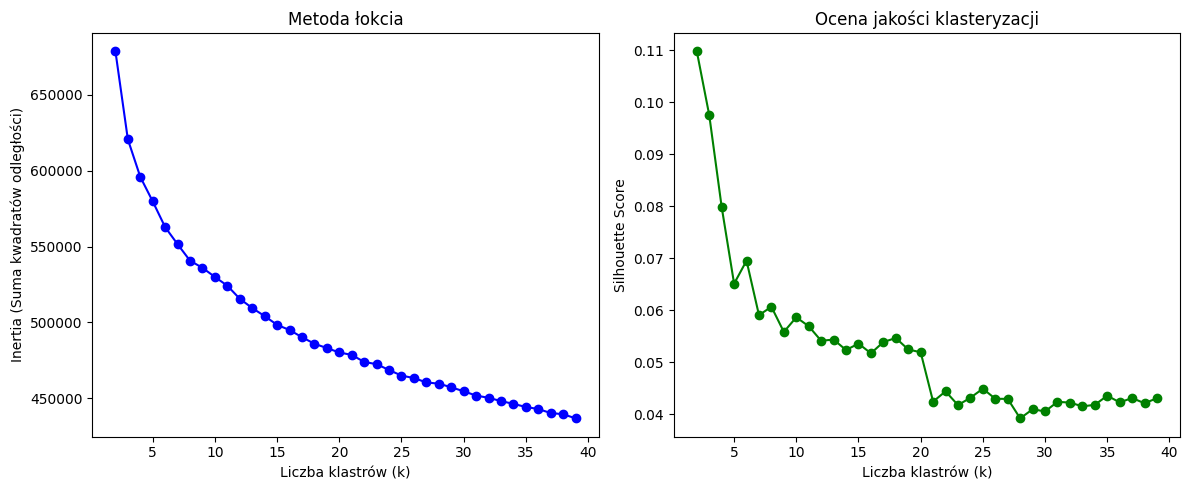

In [145]:
df=df_vit_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])

X = df.values 

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 40)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=66)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [146]:
results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=66)
    labels = kmeans.fit_predict(X)  

    sil = silhouette_score(X, labels)
    calinski = calinski_harabasz_score(X, labels)
    davies = davies_bouldin_score(X, labels)

    results.append((k, sil, calinski, davies))

df_kmeans_scores = pd.DataFrame(results, columns=['k', 'silhouette', 'calinski', 'davies'])

print(df_kmeans_scores)

   k  silhouette    calinski    davies
0  2    0.109842  261.335191  2.791528
1  3    0.097565  243.275655  2.431439
2  4    0.079896  198.507682  2.726375
3  5    0.065140  167.900595  2.860442
4  6    0.069562  151.242055  2.691239


In [195]:
df_vit_pca_copy2 = df_vit_pca.copy()
df_vit_pca_copy2.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC100,PC101,PC102,PC103,PC104,PC105,PC106,filename,pistachio_type,pistachio_type_encoded
0,7.304579,-9.837412,-3.997300,1.985668,0.479490,-1.261129,1.888987,0.396557,1.509670,1.568997,...,0.089387,0.230217,1.502255,-0.573554,-0.130237,-1.254077,-0.604874,kirmizi (1).jpg,kirmizi,0
1,6.040486,-10.007254,0.162019,-4.587778,-4.879454,3.868066,4.239974,-6.237411,0.135013,0.427599,...,-1.070216,0.316928,-0.339624,-0.754598,0.574288,0.199413,-0.469312,kirmizi (10).jpg,kirmizi,0
2,-2.948353,-3.131220,-3.108559,6.225791,-0.665489,1.051404,-4.210718,-1.120366,1.683365,0.319224,...,-0.310875,0.435443,0.221247,-0.217096,-0.046031,-0.038612,0.382909,kirmizi (11).jpg,kirmizi,0
3,14.987496,-3.274644,2.602210,1.914061,-8.532184,3.967622,1.012263,0.876515,-2.551190,3.432236,...,-2.154131,0.761118,1.063026,-0.150578,-0.958870,-0.026531,-0.190403,kirmizi (12).jpg,kirmizi,0
4,6.504495,-9.850962,12.350292,-2.092597,-7.669635,4.985795,-4.742768,-3.898370,-4.132975,1.058235,...,-1.127061,0.684127,-0.263264,0.808421,0.208188,-0.446413,0.574842,kirmizi (13).jpg,kirmizi,0


In [196]:
X = df_vit_pca_copy2.drop(columns=['filename', 'pistachio_type', 'pistachio_type_encoded'])  
kmeans = KMeans(n_clusters=5, random_state=66)
df_vit_pca_copy2['cluster'] = kmeans.fit_predict(X)
df_vit_pca_copy2['cluster'].value_counts()

cluster
0    490
4    478
3    467
1    389
2    324
Name: count, dtype: int64

In [197]:
pd.crosstab(df_vit_pca_copy2['cluster'], df_vit_pca_copy2['pistachio_type_encoded'])

pistachio_type_encoded,0,1
cluster,,
0,434,56
1,355,34
2,56,268
3,299,168
4,88,390


DBSCAN

In [205]:
df_pca_dbscan = df_pca.copy()
df_pca_dbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC423,PC424,PC425,PC426,PC427,PC428,PC429,filename,pistachio_type,pistachio_type_encoded
0,0.194712,-22.051676,-5.167302,-6.702526,-0.445801,-1.698404,0.467875,-7.896684,-3.233660,6.107592,...,0.104181,-0.202404,0.391603,0.324335,0.190983,0.004123,-0.745335,kirmizi (1).jpg,kirmizi,0
1,-19.589283,-13.726288,-2.288669,1.831107,-2.287663,-5.773524,-9.959004,12.865578,9.575318,6.997399,...,-0.253038,0.152521,-0.011924,0.075651,0.196779,0.576208,0.281170,kirmizi (10).jpg,kirmizi,0
2,8.625244,-1.821266,9.637932,-11.614676,9.166008,2.770771,15.009316,-7.818260,-10.980262,-7.767596,...,0.249025,0.514209,-0.145273,0.258718,-0.882969,0.114371,-0.145647,kirmizi (11).jpg,kirmizi,0
3,-3.856548,-17.693206,8.970494,17.634634,15.218493,11.543478,-7.617486,12.540399,9.367644,5.179373,...,0.596049,-0.107307,-0.376038,0.301090,-0.037336,0.855761,0.132147,kirmizi (12).jpg,kirmizi,0
4,-17.062005,-2.570202,13.446926,11.487373,10.947447,-1.218870,-23.831213,-2.797485,4.535761,-7.252758,...,0.174999,0.307570,-0.384885,0.917544,-0.159767,-0.669713,-0.523078,kirmizi (13).jpg,kirmizi,0


In [206]:
from sklearn.cluster import DBSCAN
df=df_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

dbscan = DBSCAN(eps=19, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

df_pca_dbscan['cluster_DBSCAN'] = labels
df_pca_dbscan['cluster_DBSCAN'].value_counts()

cluster_DBSCAN
-1    1966
 0     182
Name: count, dtype: int64

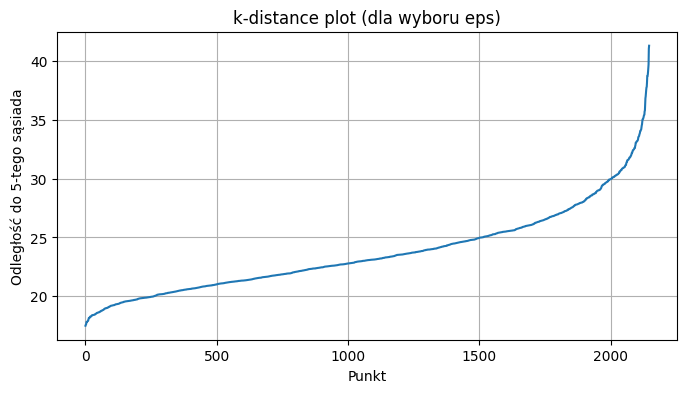

In [207]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("k-distance plot (dla wyboru eps)")
plt.xlabel("Punkt")
plt.ylabel("Odległość do 5-tego sąsiada")
plt.grid(True)
plt.show()

In [208]:
df=df_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

best_score = -1
best_params = {}

results = []
cluster_info = []

eps_values = np.arange(17,35,1)
min_samples_values = range(3,5)

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info.append((eps, min_samples, n_clusters, n_noise))

        if len(set(labels)) > 1 and -1 in labels:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((eps, min_samples, score))
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
            except:
                continue

print("Najlepsze parametry:")
print(best_params)
print("Silhouette score:", best_score)

df_results = pd.DataFrame(results, columns=['eps', 'min_samples', 'silhouette'])

eps=17, min_samples=3, clusters=0, noise=2148
eps=17, min_samples=4, clusters=0, noise=2148
eps=18, min_samples=3, clusters=1, noise=2090
eps=18, min_samples=4, clusters=1, noise=2100
eps=19, min_samples=3, clusters=1, noise=1966
eps=19, min_samples=4, clusters=1, noise=1970
eps=20, min_samples=3, clusters=1, noise=1732
eps=20, min_samples=4, clusters=1, noise=1740
eps=21, min_samples=3, clusters=1, noise=1443
eps=21, min_samples=4, clusters=1, noise=1449
eps=22, min_samples=3, clusters=1, noise=1173
eps=22, min_samples=4, clusters=1, noise=1177
eps=23, min_samples=3, clusters=1, noise=917
eps=23, min_samples=4, clusters=1, noise=918
eps=24, min_samples=3, clusters=1, noise=738
eps=24, min_samples=4, clusters=1, noise=740
eps=25, min_samples=3, clusters=1, noise=543
eps=25, min_samples=4, clusters=1, noise=544
eps=26, min_samples=3, clusters=1, noise=390
eps=26, min_samples=4, clusters=1, noise=392
eps=27, min_samples=3, clusters=1, noise=295
eps=27, min_samples=4, clusters=1, noise=29

In [209]:
df=df_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

dbscan = DBSCAN(eps=18, min_samples=3)
labels = dbscan.fit_predict(X_scaled)

df_pca_dbscan['cluster_DBSCAN'] = labels
df_pca_dbscan['cluster_DBSCAN'].value_counts()

cluster_DBSCAN
-1    2090
 0      58
Name: count, dtype: int64

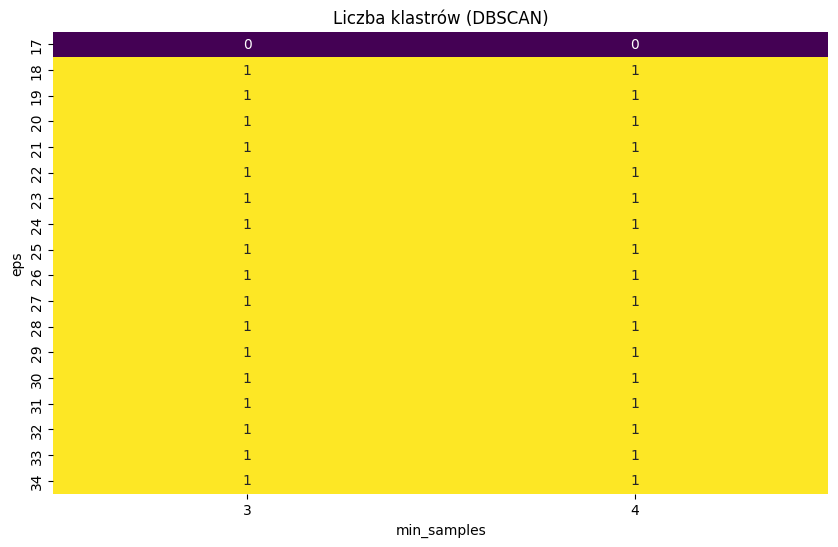

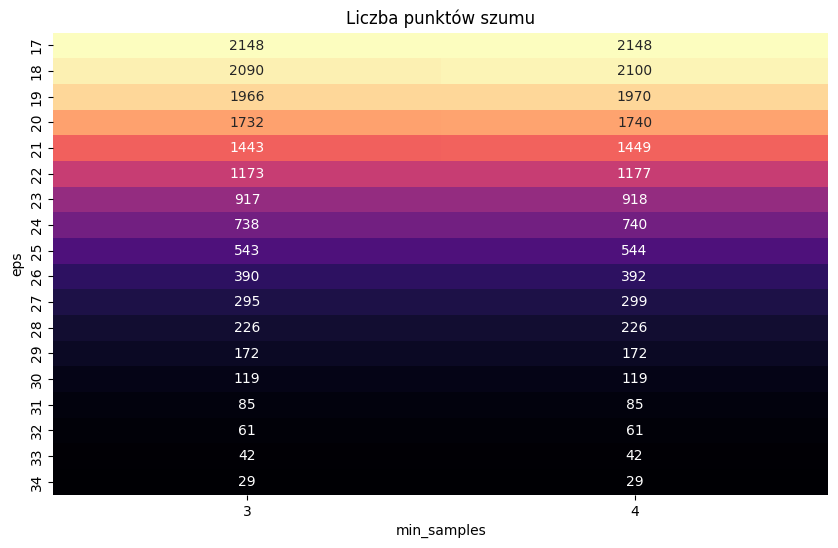

In [212]:
import seaborn as sns
df_clusters = pd.DataFrame(cluster_info, columns=['eps', 'min_samples', 'n_clusters', 'n_noise'])

pivot_clusters = df_clusters.pivot(index='eps', columns='min_samples', values='n_clusters')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_clusters, annot=True, cmap='viridis', fmt='d',cbar=False)
plt.title('Liczba klastrów (DBSCAN)')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

pivot_noise = df_clusters.pivot(index='eps', columns='min_samples', values='n_noise')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_noise, annot=True, cmap='magma', fmt='d',cbar=False)
plt.title('Liczba punktów szumu')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

In [226]:
df_resnet_pca_dbscan = df_resnet_pca.copy()
df_resnet_pca_dbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC338,PC339,PC340,PC341,PC342,PC343,PC344,filename,pistachio_type,pistachio_type_encoded
0,-3.551248,-17.716654,-3.624884,-9.096153,0.873164,-3.028066,-7.442551,-1.202262,6.060190,4.015378,...,-0.249735,-0.236001,0.457911,1.572232,0.056190,-0.393799,-0.622427,kirmizi (1).jpg,kirmizi,0
1,18.114607,-10.628550,-0.125958,-1.240595,-0.496131,-4.580767,4.518785,4.638251,-17.036196,9.377854,...,-0.584974,0.791133,0.687179,-0.438755,-0.238210,-0.161150,-0.207785,kirmizi (10).jpg,kirmizi,0
2,-12.019251,1.186817,8.105490,-10.688737,8.078110,3.220982,1.191720,-8.353822,15.078301,-9.268645,...,-0.726261,-0.557533,0.182393,-0.143124,0.726360,-0.138818,-0.047433,kirmizi (11).jpg,kirmizi,0
3,5.073485,-14.614056,9.726931,16.452125,8.826621,17.303189,6.546224,8.572450,0.867451,-0.375183,...,-0.331342,-0.904977,0.742135,-0.546309,0.326899,-0.757499,0.353910,kirmizi (12).jpg,kirmizi,0
4,15.393349,0.993230,10.639720,12.965910,10.972967,2.459127,-12.351388,0.599412,-12.540456,-7.980769,...,0.046954,-0.711882,-0.693842,0.667925,1.713752,-0.709272,0.017899,kirmizi (13).jpg,kirmizi,0


In [233]:
from sklearn.cluster import DBSCAN
df=df_resnet_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

dbscan = DBSCAN(eps=27, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

df_resnet_pca_dbscan['cluster_DBSCAN'] = labels
df_resnet_pca_dbscan['cluster_DBSCAN'].value_counts()

cluster_DBSCAN
 0    2023
-1     125
Name: count, dtype: int64

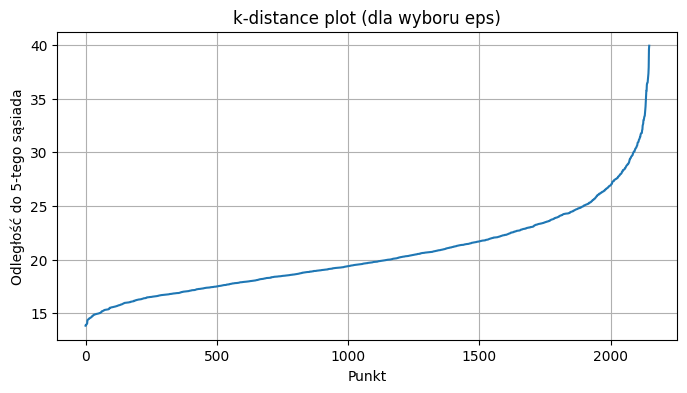

In [230]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("k-distance plot (dla wyboru eps)")
plt.xlabel("Punkt")
plt.ylabel("Odległość do 5-tego sąsiada")
plt.grid(True)
plt.show()

In [234]:
df=df_resnet_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

best_score = -1
best_params = {}

results = []
cluster_info = []

eps_values = np.arange(25,30,1)
min_samples_values = range(3,5)

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info.append((eps, min_samples, n_clusters, n_noise))

        if len(set(labels)) > 1 and -1 in labels:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((eps, min_samples, score))
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
            except:
                continue

print("Najlepsze parametry:")
print(best_params)
print("Silhouette score:", best_score)

df_results = pd.DataFrame(results, columns=['eps', 'min_samples', 'silhouette'])

eps=25, min_samples=3, clusters=1, noise=216
eps=25, min_samples=4, clusters=1, noise=217
eps=26, min_samples=3, clusters=1, noise=167
eps=26, min_samples=4, clusters=1, noise=167
eps=27, min_samples=3, clusters=1, noise=125
eps=27, min_samples=4, clusters=1, noise=125
eps=28, min_samples=3, clusters=1, noise=93
eps=28, min_samples=4, clusters=1, noise=93
eps=29, min_samples=3, clusters=1, noise=72
eps=29, min_samples=4, clusters=1, noise=72
Najlepsze parametry:
{}
Silhouette score: -1


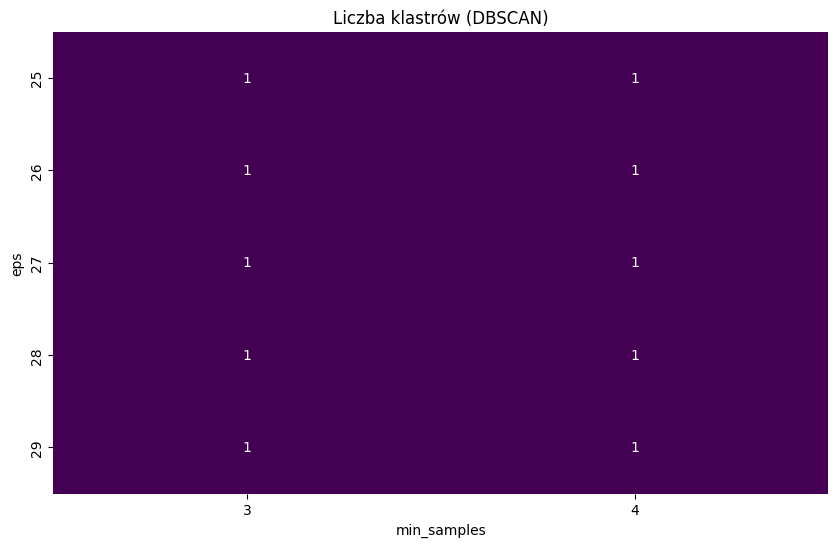

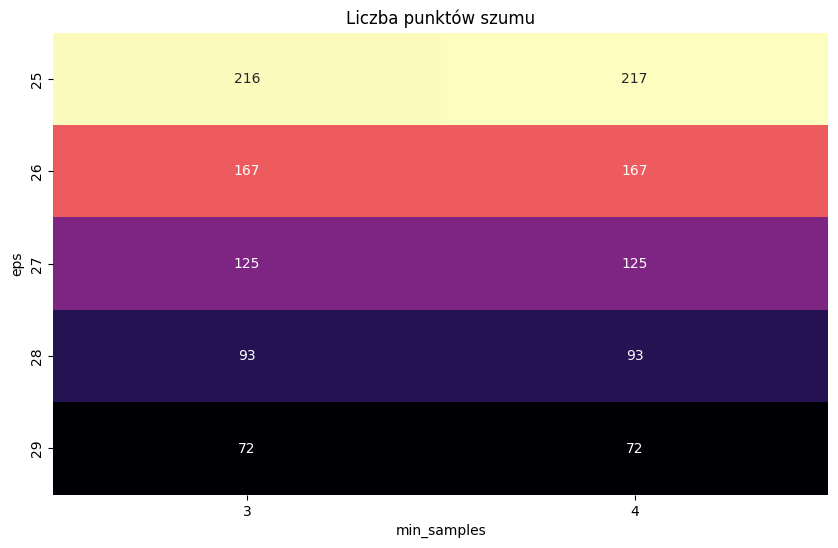

In [235]:
df_clusters = pd.DataFrame(cluster_info, columns=['eps', 'min_samples', 'n_clusters', 'n_noise'])

pivot_clusters = df_clusters.pivot(index='eps', columns='min_samples', values='n_clusters')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_clusters, annot=True, cmap='viridis', fmt='d',cbar=False)
plt.title('Liczba klastrów (DBSCAN)')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

pivot_noise = df_clusters.pivot(index='eps', columns='min_samples', values='n_noise')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_noise, annot=True, cmap='magma', fmt='d',cbar=False)
plt.title('Liczba punktów szumu')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

In [236]:
df_vit_pca_dbscan = df_vit_pca.copy()
df_vit_pca_dbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC100,PC101,PC102,PC103,PC104,PC105,PC106,filename,pistachio_type,pistachio_type_encoded
0,7.304579,-9.837412,-3.997300,1.985668,0.479490,-1.261129,1.888987,0.396557,1.509670,1.568997,...,0.089387,0.230217,1.502255,-0.573554,-0.130237,-1.254077,-0.604874,kirmizi (1).jpg,kirmizi,0
1,6.040486,-10.007254,0.162019,-4.587778,-4.879454,3.868066,4.239974,-6.237411,0.135013,0.427599,...,-1.070216,0.316928,-0.339624,-0.754598,0.574288,0.199413,-0.469312,kirmizi (10).jpg,kirmizi,0
2,-2.948353,-3.131220,-3.108559,6.225791,-0.665489,1.051404,-4.210718,-1.120366,1.683365,0.319224,...,-0.310875,0.435443,0.221247,-0.217096,-0.046031,-0.038612,0.382909,kirmizi (11).jpg,kirmizi,0
3,14.987496,-3.274644,2.602210,1.914061,-8.532184,3.967622,1.012263,0.876515,-2.551190,3.432236,...,-2.154131,0.761118,1.063026,-0.150578,-0.958870,-0.026531,-0.190403,kirmizi (12).jpg,kirmizi,0
4,6.504495,-9.850962,12.350292,-2.092597,-7.669635,4.985795,-4.742768,-3.898370,-4.132975,1.058235,...,-1.127061,0.684127,-0.263264,0.808421,0.208188,-0.446413,0.574842,kirmizi (13).jpg,kirmizi,0


In [237]:
from sklearn.cluster import DBSCAN
df=df_vit_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

dbscan = DBSCAN(eps=10, min_samples=4)
labels = dbscan.fit_predict(X_scaled)

df_vit_pca_dbscan['cluster_DBSCAN'] = labels
df_vit_pca_dbscan['cluster_DBSCAN'].value_counts()

cluster_DBSCAN
-1    1492
 0     645
 1       4
 3       4
 2       3
Name: count, dtype: int64

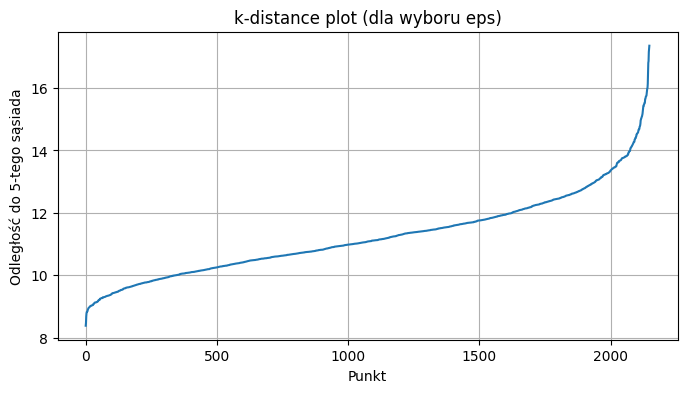

In [238]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4]) 
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("k-distance plot (dla wyboru eps)")
plt.xlabel("Punkt")
plt.ylabel("Odległość do 5-tego sąsiada")
plt.grid(True)
plt.show()

In [239]:
df=df_vit_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

best_score = -1
best_params = {}

results = []
cluster_info = []

eps_values = np.arange(10,14,1)
min_samples_values = range(3,5)

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info.append((eps, min_samples, n_clusters, n_noise))

        if len(set(labels)) > 1 and -1 in labels:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((eps, min_samples, score))
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samples}
            except:
                continue

print("Najlepsze parametry:")
print(best_params)
print("Silhouette score:", best_score)

df_results = pd.DataFrame(results, columns=['eps', 'min_samples', 'silhouette'])

eps=10, min_samples=3, clusters=8, noise=1456
eps=10, min_samples=4, clusters=4, noise=1492
eps=11, min_samples=3, clusters=1, noise=750
eps=11, min_samples=4, clusters=1, noise=769
eps=12, min_samples=3, clusters=1, noise=291
eps=12, min_samples=4, clusters=1, noise=303
eps=13, min_samples=3, clusters=1, noise=100
eps=13, min_samples=4, clusters=1, noise=105
Najlepsze parametry:
{'eps': 10, 'min_samples': 4}
Silhouette score: 0.004148124639444429


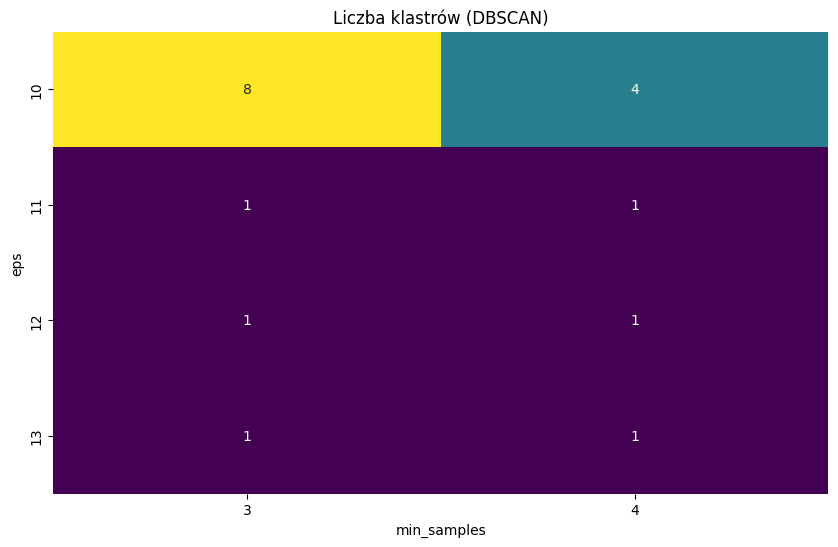

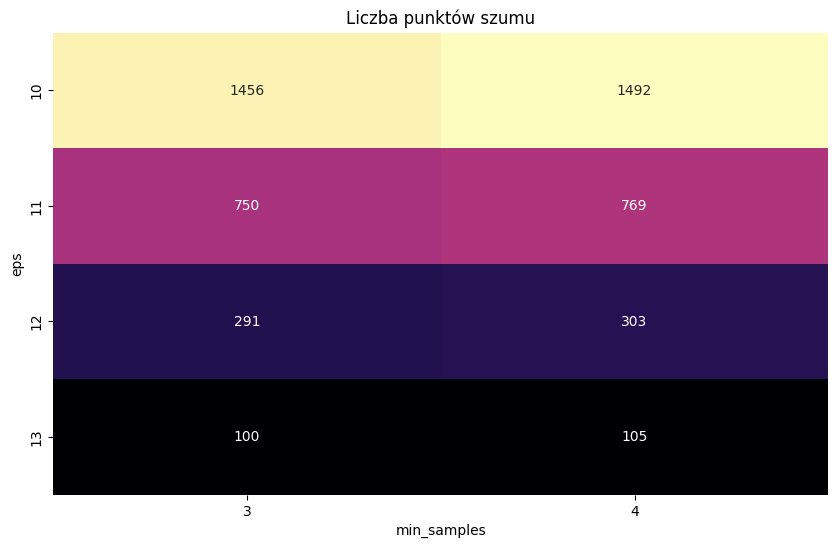

In [240]:
df_clusters = pd.DataFrame(cluster_info, columns=['eps', 'min_samples', 'n_clusters', 'n_noise'])

pivot_clusters = df_clusters.pivot(index='eps', columns='min_samples', values='n_clusters')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_clusters, annot=True, cmap='viridis', fmt='d',cbar=False)
plt.title('Liczba klastrów (DBSCAN)')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

pivot_noise = df_clusters.pivot(index='eps', columns='min_samples', values='n_noise')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_noise, annot=True, cmap='magma', fmt='d',cbar=False)
plt.title('Liczba punktów szumu')
plt.xlabel('min_samples')
plt.ylabel('eps')
plt.show()

HDBSCAN

In [243]:
import warnings
warnings.filterwarnings('ignore')
import hdbscan

In [244]:
df_pca_hdbscan = df_pca.copy()
df_pca_hdbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC423,PC424,PC425,PC426,PC427,PC428,PC429,filename,pistachio_type,pistachio_type_encoded
0,0.194712,-22.051676,-5.167302,-6.702526,-0.445801,-1.698404,0.467875,-7.896684,-3.233660,6.107592,...,0.104181,-0.202404,0.391603,0.324335,0.190983,0.004123,-0.745335,kirmizi (1).jpg,kirmizi,0
1,-19.589283,-13.726288,-2.288669,1.831107,-2.287663,-5.773524,-9.959004,12.865578,9.575318,6.997399,...,-0.253038,0.152521,-0.011924,0.075651,0.196779,0.576208,0.281170,kirmizi (10).jpg,kirmizi,0
2,8.625244,-1.821266,9.637932,-11.614676,9.166008,2.770771,15.009316,-7.818260,-10.980262,-7.767596,...,0.249025,0.514209,-0.145273,0.258718,-0.882969,0.114371,-0.145647,kirmizi (11).jpg,kirmizi,0
3,-3.856548,-17.693206,8.970494,17.634634,15.218493,11.543478,-7.617486,12.540399,9.367644,5.179373,...,0.596049,-0.107307,-0.376038,0.301090,-0.037336,0.855761,0.132147,kirmizi (12).jpg,kirmizi,0
4,-17.062005,-2.570202,13.446926,11.487373,10.947447,-1.218870,-23.831213,-2.797485,4.535761,-7.252758,...,0.174999,0.307570,-0.384885,0.917544,-0.159767,-0.669713,-0.523078,kirmizi (13).jpg,kirmizi,0


In [245]:
df=df_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5) 
labels = clusterer.fit_predict(X_scaled)

df_pca_hdbscan['cluster_hdbscan'] = labels
df_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2148
Name: count, dtype: int64

In [246]:
results = []
best_score = -1
best_params = {}

cluster_info2 = []

min_cluster_sizes = [2,3]
min_samples_values = [3,4,5,6]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        labels = clusterer.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        print(f"min_cluster_size={min_cluster_size}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info2.append((min_cluster_size, min_samples, n_clusters, n_noise))

        if n_clusters >= 2:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((min_cluster_size, min_samples, n_clusters, n_noise, score))
                if score > best_score:
                    best_score = score
                    best_params = {
                        'min_cluster_size': min_cluster_size,
                        'min_samples': min_samples
                    }
            except:
                continue

print("Najlepsze parametry:", best_params)
print("Silhouette score:", best_score)

df_hdbscan_results = pd.DataFrame(results, columns=[
    'min_cluster_size', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'
])

min_cluster_size=2, min_samples=3, clusters=3, noise=2137
min_cluster_size=2, min_samples=4, clusters=2, noise=2137
min_cluster_size=2, min_samples=5, clusters=2, noise=2141
min_cluster_size=2, min_samples=6, clusters=0, noise=2148
min_cluster_size=3, min_samples=3, clusters=2, noise=2133
min_cluster_size=3, min_samples=4, clusters=2, noise=2137
min_cluster_size=3, min_samples=5, clusters=0, noise=2148
min_cluster_size=3, min_samples=6, clusters=0, noise=2148
Najlepsze parametry: {'min_cluster_size': 2, 'min_samples': 5}
Silhouette score: 0.05070699314087589


In [247]:
df=df_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=5) 
labels = clusterer.fit_predict(X_scaled)

df_pca_hdbscan['cluster_hdbscan'] = labels
df_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2141
 0       5
 1       2
Name: count, dtype: int64

In [248]:
df_resnet_pca_hdbscan = df_resnet_pca.copy()
df_resnet_pca_hdbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC338,PC339,PC340,PC341,PC342,PC343,PC344,filename,pistachio_type,pistachio_type_encoded
0,-3.551248,-17.716654,-3.624884,-9.096153,0.873164,-3.028066,-7.442551,-1.202262,6.060190,4.015378,...,-0.249735,-0.236001,0.457911,1.572232,0.056190,-0.393799,-0.622427,kirmizi (1).jpg,kirmizi,0
1,18.114607,-10.628550,-0.125958,-1.240595,-0.496131,-4.580767,4.518785,4.638251,-17.036196,9.377854,...,-0.584974,0.791133,0.687179,-0.438755,-0.238210,-0.161150,-0.207785,kirmizi (10).jpg,kirmizi,0
2,-12.019251,1.186817,8.105490,-10.688737,8.078110,3.220982,1.191720,-8.353822,15.078301,-9.268645,...,-0.726261,-0.557533,0.182393,-0.143124,0.726360,-0.138818,-0.047433,kirmizi (11).jpg,kirmizi,0
3,5.073485,-14.614056,9.726931,16.452125,8.826621,17.303189,6.546224,8.572450,0.867451,-0.375183,...,-0.331342,-0.904977,0.742135,-0.546309,0.326899,-0.757499,0.353910,kirmizi (12).jpg,kirmizi,0
4,15.393349,0.993230,10.639720,12.965910,10.972967,2.459127,-12.351388,0.599412,-12.540456,-7.980769,...,0.046954,-0.711882,-0.693842,0.667925,1.713752,-0.709272,0.017899,kirmizi (13).jpg,kirmizi,0


In [249]:
df=df_resnet_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5) 
labels = clusterer.fit_predict(X_scaled)

df_resnet_pca_hdbscan['cluster_hdbscan'] = labels
df_resnet_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2148
Name: count, dtype: int64

In [250]:
results = []
best_score = -1
best_params = {}

cluster_info2 = []

min_cluster_sizes = [2,3]
min_samples_values = [3,4,5,6]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        labels = clusterer.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        print(f"min_cluster_size={min_cluster_size}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info2.append((min_cluster_size, min_samples, n_clusters, n_noise))

        if n_clusters >= 2:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((min_cluster_size, min_samples, n_clusters, n_noise, score))
                if score > best_score:
                    best_score = score
                    best_params = {
                        'min_cluster_size': min_cluster_size,
                        'min_samples': min_samples
                    }
            except:
                continue

print("Najlepsze parametry:", best_params)
print("Silhouette score:", best_score)

df_hdbscan_results = pd.DataFrame(results, columns=[
    'min_cluster_size', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'
])

min_cluster_size=2, min_samples=3, clusters=3, noise=2132
min_cluster_size=2, min_samples=4, clusters=2, noise=2142
min_cluster_size=2, min_samples=5, clusters=2, noise=2142
min_cluster_size=2, min_samples=6, clusters=2, noise=2143
min_cluster_size=3, min_samples=3, clusters=2, noise=2140
min_cluster_size=3, min_samples=4, clusters=0, noise=2148
min_cluster_size=3, min_samples=5, clusters=2, noise=2142
min_cluster_size=3, min_samples=6, clusters=0, noise=2148
Najlepsze parametry: {'min_cluster_size': 2, 'min_samples': 6}
Silhouette score: 0.06626736917263881


In [252]:
df=df_resnet_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=6) 
labels = clusterer.fit_predict(X_scaled)

df_resnet_pca_hdbscan['cluster_hdbscan'] = labels
df_resnet_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2143
 0       3
 1       2
Name: count, dtype: int64

In [253]:
df_vit_pca_hdbscan = df_vit_pca.copy()
df_vit_pca_hdbscan.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC100,PC101,PC102,PC103,PC104,PC105,PC106,filename,pistachio_type,pistachio_type_encoded
0,7.304579,-9.837412,-3.997300,1.985668,0.479490,-1.261129,1.888987,0.396557,1.509670,1.568997,...,0.089387,0.230217,1.502255,-0.573554,-0.130237,-1.254077,-0.604874,kirmizi (1).jpg,kirmizi,0
1,6.040486,-10.007254,0.162019,-4.587778,-4.879454,3.868066,4.239974,-6.237411,0.135013,0.427599,...,-1.070216,0.316928,-0.339624,-0.754598,0.574288,0.199413,-0.469312,kirmizi (10).jpg,kirmizi,0
2,-2.948353,-3.131220,-3.108559,6.225791,-0.665489,1.051404,-4.210718,-1.120366,1.683365,0.319224,...,-0.310875,0.435443,0.221247,-0.217096,-0.046031,-0.038612,0.382909,kirmizi (11).jpg,kirmizi,0
3,14.987496,-3.274644,2.602210,1.914061,-8.532184,3.967622,1.012263,0.876515,-2.551190,3.432236,...,-2.154131,0.761118,1.063026,-0.150578,-0.958870,-0.026531,-0.190403,kirmizi (12).jpg,kirmizi,0
4,6.504495,-9.850962,12.350292,-2.092597,-7.669635,4.985795,-4.742768,-3.898370,-4.132975,1.058235,...,-1.127061,0.684127,-0.263264,0.808421,0.208188,-0.446413,0.574842,kirmizi (13).jpg,kirmizi,0


In [254]:
df=df_vit_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5) 
labels = clusterer.fit_predict(X_scaled)

df_vit_pca_hdbscan['cluster_hdbscan'] = labels
df_vit_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2071
 0      72
 1       5
Name: count, dtype: int64

In [255]:
results = []
best_score = -1
best_params = {}

cluster_info2 = []

min_cluster_sizes = [2,3]
min_samples_values = [3,4,5,6]

for min_cluster_size in min_cluster_sizes:
    for min_samples in min_samples_values:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        labels = clusterer.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        print(f"min_cluster_size={min_cluster_size}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}")
        cluster_info2.append((min_cluster_size, min_samples, n_clusters, n_noise))

        if n_clusters >= 2:
            try:
                score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
                results.append((min_cluster_size, min_samples, n_clusters, n_noise, score))
                if score > best_score:
                    best_score = score
                    best_params = {
                        'min_cluster_size': min_cluster_size,
                        'min_samples': min_samples
                    }
            except:
                continue

print("Najlepsze parametry:", best_params)
print("Silhouette score:", best_score)

df_hdbscan_results = pd.DataFrame(results, columns=[
    'min_cluster_size', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'
])

min_cluster_size=2, min_samples=3, clusters=2, noise=936
min_cluster_size=2, min_samples=4, clusters=2, noise=1743
min_cluster_size=2, min_samples=5, clusters=3, noise=1843
min_cluster_size=2, min_samples=6, clusters=2, noise=2076
min_cluster_size=3, min_samples=3, clusters=2, noise=1690
min_cluster_size=3, min_samples=4, clusters=2, noise=1985
min_cluster_size=3, min_samples=5, clusters=2, noise=2071
min_cluster_size=3, min_samples=6, clusters=3, noise=2130
Najlepsze parametry: {'min_cluster_size': 3, 'min_samples': 6}
Silhouette score: 0.06869620980064577


In [256]:
df=df_vit_pca.drop(columns=['filename',	'pistachio_type', 'pistachio_type_encoded'])
X_scaled = scaler.fit_transform(df)

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=6) 
labels = clusterer.fit_predict(X_scaled)

df_vit_pca_hdbscan['cluster_hdbscan'] = labels
df_vit_pca_hdbscan['cluster_hdbscan'].value_counts()

cluster_hdbscan
-1    2130
 0       9
 1       6
 2       3
Name: count, dtype: int64